In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt

from dataclasses import dataclass, field
from typing import Optional, Tuple, List, Dict

# A simple sequential task: a "piece" has L note positions (states),
# each requires the correct action among A possible notes/keys.
# Reward: +1 for correct move (advance to next state), -0.1 otherwise.
# Episode ends when the piece is completed (reach terminal after L correct notes)
# or when a max step budget is reached.

class PianoEnv:
    def __init__(self, length : int = 20,  n_actions: int = 10, max_steps: Optional[int] = None, seed: int = 0):
        self.length = length-1
        self.n_states = length 
        self.n_actions = n_actions
        self.state = 0
        self.rng = random.Random(seed)
        self.np_rng = np.random.default_rng(seed)
        # "Score" mapping from state -> correct action (fixed unknown function)
        self.correct_map = [self.rng.randrange(n_actions) for _ in range(length)]
        print("Correct map:", self.correct_map)
        self.max_steps = max_steps if max_steps is not None else 2 * length
        #FIXME
        allowed_actions_map = None

        # If not provided, allow all actions at all states
        if allowed_actions_map is None:
            self.allowed_actions_map = [list(range(n_actions)) for _ in range(length)]

    def reset(self) -> int:
        self.state = 0
        self.steps = 0
        return self.state

    def step(self, action: int) -> Tuple[int, float, bool, Dict]:
        self.steps += 1
        done = False
        reward = -0.8
        if action == self.correct_map[self.state]:
            reward = 1.0
            self.state += 1
            if self.state >= self.length:
                done = True
        if self.steps >= self.max_steps:
            done = True
        return self.state, reward, done, {}
         
    def allowed_actions(self, state: int) -> List[int]:
        return self.allowed_actions_map[state]


# ------------------------------
# RL Agent (Q-learning)
# ------------------------------
class QLearningAgent:
    def __init__(self, n_states, n_actions, lr=0.1, gamma=0.95, eps=0.1):
        self.n_states = n_states
        self.n_actions = n_actions
        self.Q = np.zeros((n_states, n_actions))
        self.lr = lr
        self.gamma = gamma
        self.eps = eps

    def start_episode(self):
        pass

    def act(self, state, allowed):
        if random.random() < self.eps:
            return random.choice(allowed)
        return int(np.argmax(self.Q[state, allowed]))

    def update(self, s, a, r, s_next, done):
        best_next = np.max(self.Q[s_next])
        target = r + (0 if done else self.gamma * best_next)
        self.Q[s, a] += self.lr * (target - self.Q[s, a])

    # def update_role_based(self, s, a, r, s_next, done, role="performer", obs_factor=0.3):
    #     if role == "performer":
    #         self.update(s, a, r, s_next, done)
    #     else:  # weaker update during observation
    #         best_next = np.max(self.Q[s_next])
    #         target = r + (0 if done else self.gamma * best_next)
    #         self.Q[s, a] += obs_factor * self.lr * (target - self.Q[s, a])

    # alternative role-based update 
    def update_role_based(self, s, a, r, s_next, done, role="performer", obs_factor=0.3, imitation_factor=0.5, performer_Q=None):
        if role == "performer":
            self.update(s, a, r, s_next, done)
        else:  # coach (observer)
            # Standard weaker TD update
            best_next = np.max(self.Q[s_next])
            target = r + (0 if done else self.gamma * best_next)
            self.Q[s, a] += obs_factor * self.lr * (target - self.Q[s, a])

            # small imitation step towards performer’s Q-values
            if performer_Q is not None:
                self.Q[s] = (1 - imitation_factor) * self.Q[s] + imitation_factor * performer_Q[s]


    def generate_action(self, state, allowed):
        return np.argmax(self.Q[state, allowed])

# ------------------------------
# Experimental Variants
# ------------------------------

def run_solo(env, agent, n_episodes=200):
    rewards = []
    for ep in range(n_episodes):
        s = env.reset()
        done = False
        ep_reward = 0
        while not done:
            a = agent.act(s, env.allowed_actions(s))
            s_next, r, done, _ = env.step(a)
            agent.update(s, a, r, s_next, done)
            ep_reward += r
            s = s_next
        rewards.append(ep_reward/env.steps)
        #print(env.steps, "steps in solo")
    #print (rewards[-5:], "in solo")
    return np.array(rewards)


def run_dyad(env, a, b, n_episodes=200, swap_mode="episode", obs_factor=0.5):
    rewards = []
    divergence = []

    for ep in range(n_episodes):
        s = env.reset()
        done = False
        ep_reward = 0
        steps = 0

        # performer/coach choice
        performer_first_is_a = (ep % 2 == 0)
        performer = a if performer_first_is_a else b
        coach = b if performer_first_is_a else a

        while not done:
            steps += 1
            a_perform = performer.act(s, env.allowed_actions(s))
            s_next, r, done, _ = env.step(a_perform)

            performer.update_role_based(s, a_perform, r, s_next, done, role="performer")
            coach.update_role_based(s, a_perform, r, s_next, done, role="coach", obs_factor=obs_factor,performer_Q= performer.Q)

            ep_reward += r
            s = s_next

            if swap_mode == "step":
                performer, coach = coach, performer
            elif swap_mode == "random" and random.random() < 0.1:
                performer, coach = coach, performer
        # FIXME: is it right to count only half of the steps  in the case of dyad 
        #print (steps, 0.5*steps , "steps in dyad")
        rewards.append(ep_reward/steps)

        # measure divergence
        flat_a, flat_b = a.Q.flatten(), b.Q.flatten()
        denom = (np.linalg.norm(flat_a) * np.linalg.norm(flat_b) + 1e-12)
        cos_sim = np.dot(flat_a, flat_b) / denom
        divergence.append(1.0 - cos_sim)
    #print (rewards[-5:], "in dyad")
    return np.array(rewards), np.array(divergence)
    


Correct map: [6, 34, 11, 98, 52, 34, 13, 4, 48, 68, 71, 42, 43, 6, 20, 17, 43, 71, 42, 89, 31, 20, 0, 55, 99, 11, 76, 48, 8, 0, 40, 93, 57, 13, 5, 11, 85, 18, 16, 2, 37, 55, 73, 61, 33, 60, 4, 98, 39, 43]
[-0.637999999999999, -0.6199999999999991, -0.5839999999999992, -0.5119999999999996, -0.4579999999999997] in solo
1.0 reward during step
1.0 reward during step
1.0 reward during step
1.0 reward during step
1.0 reward during step
1.0 reward during step
1.0 reward during step
1.0 reward during step
1.0 reward during step
1.0 reward during step
1.0 reward during step
1.0 reward during step
1.0 reward during step
1.0 reward during step
1.0 reward during step
1.0 reward during step
1.0 reward during step
1.0 reward during step
1.0 reward during step
-0.8 reward during step
-0.8 reward during step
-0.8 reward during step
-0.8 reward during step
-0.8 reward during step
-0.8 reward during step
-0.8 reward during step
-0.8 reward during step
-0.8 reward during step
-0.8 reward during step
-0.8 

[-0.637999999999999, -0.5839999999999992, -0.5659999999999993, -0.5119999999999996, -0.4939999999999996] in dyad
1.0 reward during step
1.0 reward during step
1.0 reward during step
1.0 reward during step
1.0 reward during step
1.0 reward during step
1.0 reward during step
1.0 reward during step
1.0 reward during step
1.0 reward during step
1.0 reward during step
1.0 reward during step
1.0 reward during step
1.0 reward during step
1.0 reward during step
1.0 reward during step
1.0 reward during step
-0.8 reward during step
-0.8 reward during step
-0.8 reward during step
-0.8 reward during step
-0.8 reward during step
-0.8 reward during step
-0.8 reward during step
-0.8 reward during step
-0.8 reward during step
-0.8 reward during step
-0.8 reward during step
-0.8 reward during step
-0.8 reward during step
-0.8 reward during step
-0.8 reward during step
-0.8 reward during step
-0.8 reward during step
-0.8 reward during step
-0.8 reward during step
-0.8 reward during step
-0.8 reward duri

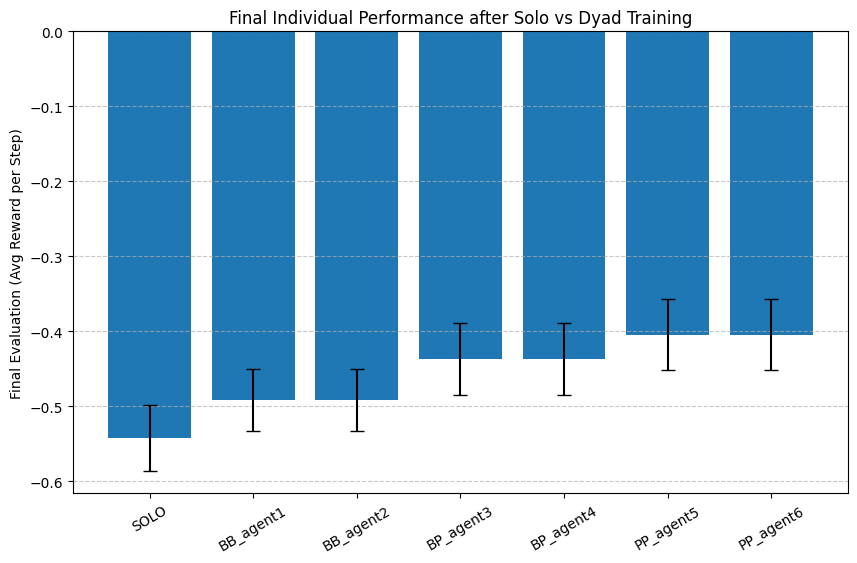

In [43]:
# ------------------------------
# Pretraining utility
# ------------------------------
def pretrain_agent(env, episodes=3):
    agent = QLearningAgent(env.n_states, env.n_actions)
    run_solo(env, agent, n_episodes=episodes)
    return agent
# ------------------------------
# Evaluation: run agent solo without updates
# ------------------------------
def evaluate_agent(env, agent, n_episodes=50):
    rewards = []
    for ep in range(n_episodes):
        s = env.reset()
        done = False
        ep_reward, steps = 0, 0
        while not done:
            a = agent.generate_action(s, env.allowed_actions(s))  # greedy choice
            s_next, r, done, _ = env.step(a)
            print (r, "reward during step")
            ep_reward += r
            steps += 1
            s = s_next
        # normalize reward per step
        rewards.append(ep_reward / steps if steps > 0 else 0.0)
    print (rewards, "during evaluation")
    return np.mean(rewards)


# ------------------------------
# Experiment: evaluate SOLO vs DYAD
# ------------------------------
def experiment_final_eval(
    n_runs=200, pretrain_episodes=5, dyad_episodes=7, solo_episodes=12, eval_episodes=2
):
    results = {
        "SOLO": [],
        "BB_agent1": [], "BB_agent2": [],
        "BP_agent3": [], "BP_agent4": [],
        "PP_agent5": [], "PP_agent6": []
    }
    sw="episode"
    for run in range(n_runs):
        seed = 123 + run
        env = PianoEnv(length=50, n_actions=100, seed=seed)

        # SOLO ----------------------
        solo_agent = QLearningAgent(env.n_states, env.n_actions)
        run_solo(env, solo_agent, n_episodes=solo_episodes)
        results["SOLO"].append(evaluate_agent(env, solo_agent, eval_episodes))

        # DYAD: Beginner+Beginner (BB) ---------
        agent1 = QLearningAgent(env.n_states, env.n_actions)
        agent2 = QLearningAgent(env.n_states, env.n_actions)
        run_dyad(env, agent1, agent2, n_episodes=dyad_episodes, swap_mode=sw, obs_factor=0.3) # FIXME: hier müsste man das irgendwie anders machen.  beginner haben einfach insgesamt weniger trials.
   
        results["BB_agent1"].append(evaluate_agent(env, agent1, eval_episodes))
        results["BB_agent2"].append(evaluate_agent(env, agent2, eval_episodes))

        # DYAD: Beginner+Pretrained (BP) -------
        agent3 = QLearningAgent(env.n_states, env.n_actions)
        pretrained = pretrain_agent(env, episodes=pretrain_episodes)
        agent4 = QLearningAgent(env.n_states, env.n_actions)
        agent4.Q = pretrained.Q.copy()
        run_dyad(env, agent3, agent4, n_episodes=dyad_episodes,
                 swap_mode=sw, obs_factor=0.3)
        results["BP_agent3"].append(evaluate_agent(env, agent3, eval_episodes))
        results["BP_agent4"].append(evaluate_agent(env, agent4, eval_episodes))

        # DYAD: Pretrained+Pretrained (PP) -----
        pretrained_a = pretrain_agent(env, episodes=pretrain_episodes)
        pretrained_b = pretrain_agent(env, episodes=pretrain_episodes)
        agent5 = QLearningAgent(env.n_states, env.n_actions); agent5.Q = pretrained_a.Q.copy()
        agent6 = QLearningAgent(env.n_states, env.n_actions); agent6.Q = pretrained_b.Q.copy()
        run_dyad(env, agent5, agent6, n_episodes=dyad_episodes,
                 swap_mode=sw, obs_factor=0.3)
        results["PP_agent5"].append(evaluate_agent(env, agent5, eval_episodes))
        results["PP_agent6"].append(evaluate_agent(env, agent6, eval_episodes))

    # Aggregate statistics
    mean_final = {k: np.mean(v) for k, v in results.items()}
    std_final  = {k: np.std(v) for k, v in results.items()}

    # Plot results
    plt.figure(figsize=(10,6))
    labels = list(mean_final.keys())
    means = [mean_final[k] for k in labels]
    stds  = [std_final[k] for k in labels]

    plt.bar(labels, means, yerr=stds, capsize=5)
    plt.xticks(rotation=30)
    plt.ylabel("Final Evaluation (Avg Reward per Step)")
    plt.title("Final Individual Performance after Solo vs Dyad Training")
    plt.grid(True, axis="y", linestyle="--", alpha=0.7)
    plt.show()

    return results, mean_final, std_final


# ------------------------------
# Run experiment
# ------------------------------
results, mean_final, std_final = experiment_final_eval(
    n_runs=20, pretrain_episodes=3, dyad_episodes=10, solo_episodes=8, eval_episodes=5
)

Correct map: [14, 3, 35, 31, 28, 17, 13, 69, 11, 75, 54, 4, 3, 11, 27, 29, 64, 77, 3, 71, 25, 69, 53, 28, 57, 75, 35, 0, 20, 54, 43, 35, 19, 27, 43, 13, 11, 48, 12, 45, 44, 77, 33, 5, 58, 68, 15, 48, 10, 70, 37, 79, 46, 73, 24, 8, 5, 29, 37, 10, 29, 12, 48, 35, 58, 46, 20, 47, 45, 26, 34, 9, 77, 21, 68, 31, 20, 59, 48, 34, 71, 28, 41, 7, 29, 4, 40, 51, 34, 8, 27, 72, 40, 27, 63, 50, 58, 18, 33, 17]
[-0.7369999999999998, -0.6919999999999993] in solo
[-0.7369999999999998, -0.7009999999999994] in solo
[-0.6469999999999985, -0.6109999999999985, -0.5839999999999986, -0.5299999999999988] in dyad
Pretrain=2, Dyad=2, A=-0.530, B=-0.530
Correct map: [14, 3, 35, 31, 28, 17, 13, 69, 11, 75, 54, 4, 3, 11, 27, 29, 64, 77, 3, 71, 25, 69, 53, 28, 57, 75, 35, 0, 20, 54, 43, 35, 19, 27, 43, 13, 11, 48, 12, 45, 44, 77, 33, 5, 58, 68, 15, 48, 10, 70, 37, 79, 46, 73, 24, 8, 5, 29, 37, 10, 29, 12, 48, 35, 58, 46, 20, 47, 45, 26, 34, 9, 77, 21, 68, 31, 20, 59, 48, 34, 71, 28, 41, 7, 29, 4, 40, 51, 34, 8, 27

[-0.1789999999999996, -0.1519999999999996, -0.13399999999999954, -0.10699999999999948, -0.07999999999999934] in dyad
Pretrain=2, Dyad=9, A=-0.080, B=-0.080
Correct map: [14, 3, 35, 31, 28, 17, 13, 69, 11, 75, 54, 4, 3, 11, 27, 29, 64, 77, 3, 71, 25, 69, 53, 28, 57, 75, 35, 0, 20, 54, 43, 35, 19, 27, 43, 13, 11, 48, 12, 45, 44, 77, 33, 5, 58, 68, 15, 48, 10, 70, 37, 79, 46, 73, 24, 8, 5, 29, 37, 10, 29, 12, 48, 35, 58, 46, 20, 47, 45, 26, 34, 9, 77, 21, 68, 31, 20, 59, 48, 34, 71, 28, 41, 7, 29, 4, 40, 51, 34, 8, 27, 72, 40, 27, 63, 50, 58, 18, 33, 17]
[-0.7369999999999998, -0.6649999999999987] in solo
[-0.7369999999999998, -0.7009999999999994] in solo
[-0.15199999999999958, -0.1069999999999995, -0.08899999999999941, -0.07099999999999927, -0.034999999999999226] in dyad
Pretrain=2, Dyad=10, A=-0.035, B=-0.035
Correct map: [14, 3, 35, 31, 28, 17, 13, 69, 11, 75, 54, 4, 3, 11, 27, 29, 64, 77, 3, 71, 25, 69, 53, 28, 57, 75, 35, 0, 20, 54, 43, 35, 19, 27, 43, 13, 11, 48, 12, 45, 44, 77, 33, 

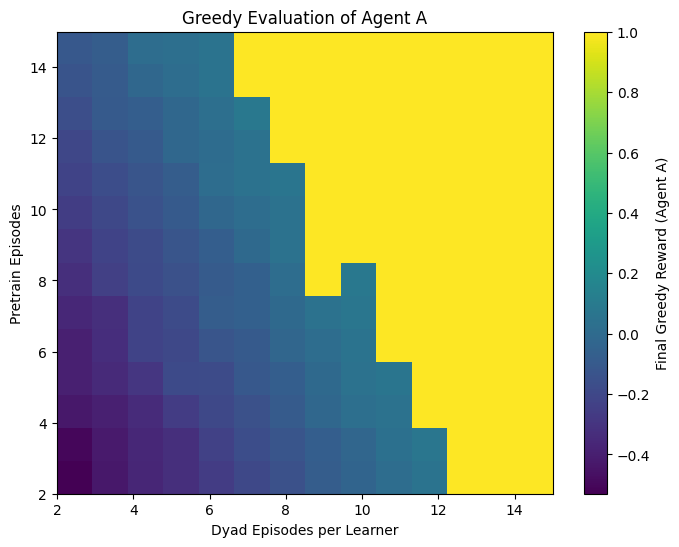

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------
# Pretraining utility
# ------------------------------
def pretrain_agent(env, episodes=3):
    agent = QLearningAgent(env.n_states, env.n_actions)
    run_solo(env, agent, n_episodes=episodes)
    return agent

# ------------------------------
# Evaluation
# ------------------------------
def evaluate_agent(env, agent, n_eval_episodes=10):
    """Greedy evaluation of a trained agent."""
    total_rewards = []
    for _ in range(n_eval_episodes):
        s = env.reset()
        done = False
        ep_reward = 0
        while not done:
            a = np.argmax(agent.Q[s])   # greedy action
            s, r, done, _ = env.step(a)
            ep_reward += r
        total_rewards.append(ep_reward/env.steps)
    return np.mean(total_rewards)

# ------------------------------
# Run one dyad experiment with variable pretraining
# ------------------------------
def run_mixed_scenario(env, pretrain_episodes, dyad_episodes, obs=0.2, swap_mode="episode"):
    """Train two pretrained agents in a dyad, then evaluate both separately."""
    agent_a = pretrain_agent(env, episodes=pretrain_episodes)
    agent_b = pretrain_agent(env, episodes=pretrain_episodes)
    
    # train in dyad
    rewards, divergence = run_dyad(env, agent_a, agent_b,
                                   n_episodes=dyad_episodes*2,
                                   swap_mode=swap_mode,
                                   obs_factor=obs)

    # evaluate each agent post-training
    eval_a = evaluate_agent(env, agent_a)
    eval_b = evaluate_agent(env, agent_b)

    return eval_a, eval_b

# ------------------------------
# Grid Experiment
# ------------------------------
def experiment_grid(pretrain_range, dyad_range, obs=0.2, swap_mode="episode"):
    
    heatmap_a = np.zeros((len(pretrain_range), len(dyad_range)))
    heatmap_b = np.zeros((len(pretrain_range), len(dyad_range)))

    for i, pretrain_episodes in enumerate(pretrain_range):
        for j, dyad_episodes in enumerate(dyad_range):
            env = PianoEnv(length=100, n_actions=80, seed=42)

            eval_a, eval_b = run_mixed_scenario(env, pretrain_episodes, dyad_episodes,
                                                obs=obs, swap_mode=swap_mode)
            heatmap_a[i, j] = eval_a
            heatmap_b[i, j] = eval_b
            print(f"Pretrain={pretrain_episodes}, Dyad={dyad_episodes}, "
                  f"A={eval_a:.3f}, B={eval_b:.3f}")

    return heatmap_a, heatmap_b

# ------------------------------
# Plotting
# ------------------------------
def plot_heatmap(pretrain_range, dyad_range, heatmap, agent_label="Learner"):
    plt.figure(figsize=(8,6))
    im = plt.imshow(heatmap, origin="lower", aspect="auto",
                    extent=[dyad_range[0], dyad_range[-1],
                            pretrain_range[0], pretrain_range[-1]],
                    cmap="viridis")
    plt.colorbar(im, label=f"Final Greedy Reward ({agent_label})")
    plt.xlabel("Dyad Episodes per Learner")
    plt.ylabel("Pretrain Episodes")
    plt.title(f"Greedy Evaluation of {agent_label}")
    plt.show()

# ------------------------------
# Run Grid Search
# ------------------------------
pretrain_range = range(2,16)   # solo training before dyad
dyad_range = range(2,16)       # dyad training length

heatmap_a, heatmap_b = experiment_grid(pretrain_range, dyad_range, obs=0.1, swap_mode="episode")

plot_heatmap(pretrain_range, dyad_range, heatmap_a, agent_label="Agent A")
#plot_heatmap(pretrain_range, dyad_range, heatmap_b, agent_label="Agent B")


Correct map: [1, 0, 4, 3, 3, 2, 1, 8, 1, 9, 6, 0, 0, 1, 3, 3, 8, 9, 0, 8]
[0.8285714285714285, 0.8285714285714285, 0.9099999999999999, 0.9099999999999999, 0.9099999999999999] in dyad
[0.9099999999999999, 0.9099999999999999, 0.9099999999999999, 0.9099999999999999, 0.9099999999999999] in solo
[0.8285714285714285, 0.6249999999999999, 0.9099999999999999, 0.7545454545454544, 0.9099999999999999] in dyad
[0.7545454545454544, 0.6869565217391305, 0.6869565217391305, 0.7545454545454546, 0.625] in solo
[0.6869565217391305, 0.7545454545454544, 0.8285714285714285, 0.7545454545454544, 0.9099999999999999] in solo
[0.7545454545454546, 0.9099999999999999, 1.0, 0.7545454545454544, 0.7545454545454546] in dyad


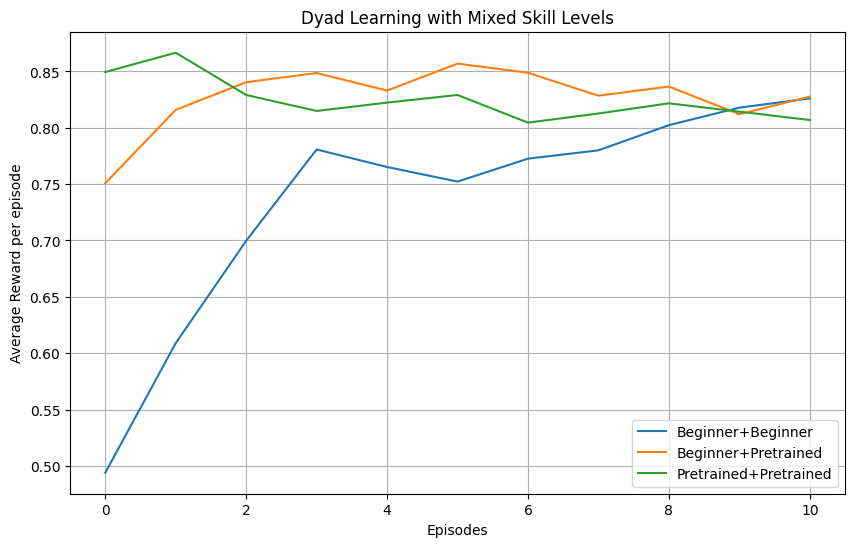

In [4]:
# FIXME: not ready, no final individual eval too. 
# ------------------------------
# Pretraining utility
# ------------------------------
def pretrain_agent(env, episodes=300):
    agent = QLearningAgent(env.n_states, env.n_actions)
    run_solo(env, agent, n_episodes=episodes)
    return agent


# ------------------------------
# Mixed-skill Experiments
# ------------------------------
def experiment_mixed_skill(n_episodes=200, pretrain_episodes=300, obs=0.2, swap_mode="episode"):
    env = PianoEnv(length=20, n_actions=10, seed=42)

    # Scenario 1: both beginners
    agent1 = QLearningAgent(env.n_states, env.n_actions)
    agent2 = QLearningAgent(env.n_states, env.n_actions)
    rewards_bb, div_bb = run_dyad(env, agent1, agent2, n_episodes=n_episodes, swap_mode=swap_mode, obs_factor=obs)

    # Scenario 2: beginner + pretrained
    agent3 = QLearningAgent(env.n_states, env.n_actions)
    pretrained = pretrain_agent(env, episodes=pretrain_episodes)
    agent4 = QLearningAgent(env.n_states, env.n_actions)
    agent4.Q = pretrained.Q.copy()   # copy pretrained knowledge
    rewards_bp, div_bp = run_dyad(env, agent3, agent4, n_episodes=n_episodes, swap_mode=swap_mode, obs_factor=obs)

    # Scenario 3: both pretrained
    pretrained_a = pretrain_agent(env, episodes=pretrain_episodes)
    pretrained_b = pretrain_agent(env, episodes=pretrain_episodes)
    agent5 = QLearningAgent(env.n_states, env.n_actions)
    agent5.Q = pretrained_a.Q.copy()
    agent6 = QLearningAgent(env.n_states, env.n_actions)
    agent6.Q = pretrained_b.Q.copy()
    rewards_pp, div_pp = run_dyad(env, agent5, agent6, n_episodes=n_episodes, swap_mode=swap_mode, obs_factor=obs)

    # Plot results
    plt.figure(figsize=(10,6))
    plt.plot(np.convolve(rewards_bb, np.ones(10)/10, mode="valid"), label="Beginner+Beginner")
    plt.plot(np.convolve(rewards_bp, np.ones(10)/10, mode="valid"), label="Beginner+Pretrained")
    plt.plot(np.convolve(rewards_pp, np.ones(10)/10, mode="valid"), label="Pretrained+Pretrained")
    plt.xlabel("Episodes")
    plt.ylabel("Average Reward per episode")
    plt.title("Dyad Learning with Mixed Skill Levels")
    plt.legend()
    plt.grid(True)
    plt.show()

    return (rewards_bb, rewards_bp, rewards_pp), (div_bb, div_bp, div_pp)


# ------------------------------
# Run the experiment
# ------------------------------
results, divergences = experiment_mixed_skill(
    n_episodes=20, pretrain_episodes=70, swap_mode="step"
)


Correct map: [6, 6, 0, 4, 8, 7, 6, 4, 7, 5, 9, 3, 8, 2, 4, 2, 1, 9, 4, 8]
[0.8285714285714285, 0.8285714285714285, 0.7545454545454544, 0.7545454545454546, 0.6869565217391305] in solo
[0.7545454545454546, 0.7545454545454544, 0.8285714285714285, 0.9099999999999999, 0.6869565217391304] in dyad


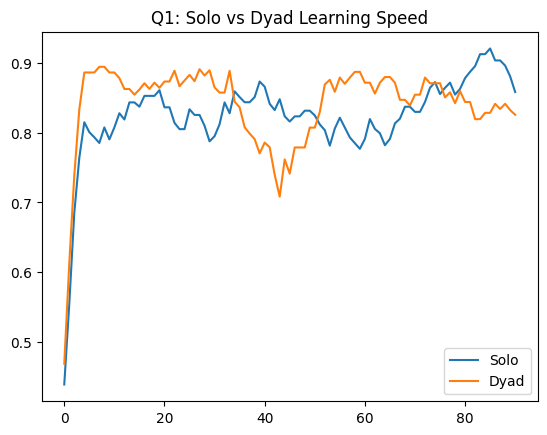

[1.0, 0.9099999999999999, 0.7545454545454546, 0.7545454545454546, 1.0] in dyad
[0.8285714285714285, 0.6249999999999999, 0.7545454545454546, 0.9099999999999999, 0.7545454545454546] in dyad
[0.9099999999999999, 0.7545454545454546, 0.9099999999999999, 0.7545454545454544, 0.7545454545454546] in dyad


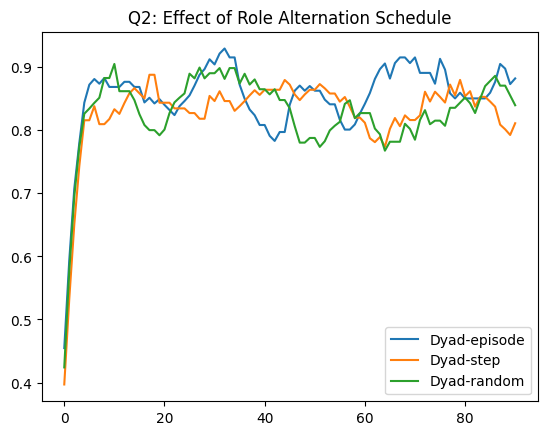

[0.9099999999999999, 0.9099999999999999, 0.7545454545454546, 1.0, 1.0] in dyad
[0.9099999999999999, 0.7545454545454546, 1.0, 1.0, 0.9099999999999999] in dyad
[1.0, 0.7545454545454546, 0.8285714285714285, 0.6869565217391304, 1.0] in dyad


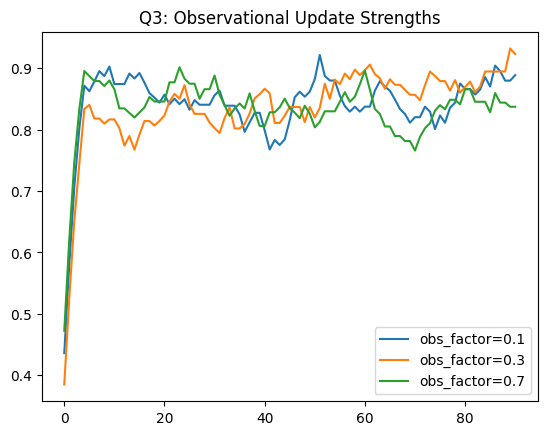

[1.0, 0.7545454545454544, 0.8285714285714285, 0.7545454545454544, 0.8285714285714285] in dyad
[0.8285714285714285, 0.9099999999999999, 1.0, 0.6249999999999999, 1.0] in dyad
[0.9099999999999999, 0.9099999999999999, 0.6249999999999999, 0.8285714285714285, 0.9099999999999999] in dyad


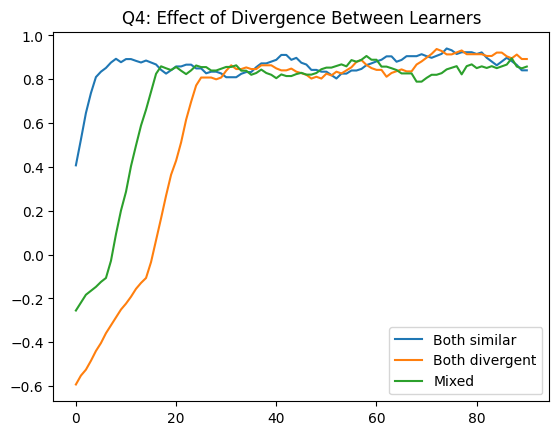

[1.0, 0.9099999999999999, 0.8285714285714285, 0.9099999999999999, 0.7545454545454544] in dyad
[1.0, 0.8285714285714285, 0.8285714285714285, 0.9099999999999999, 0.9099999999999999] in dyad
[0.9099999999999999, 0.6869565217391304, 0.9099999999999999, 1.0, 0.7545454545454544] in dyad


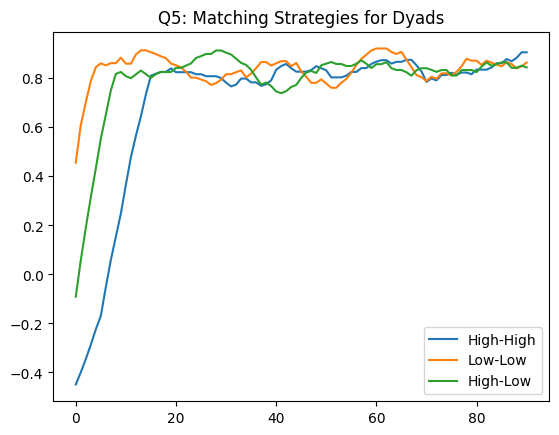

Q6: Error analysis proxy (fraction coach closer to optimal): 0.07425


In [5]:

# ------------------------------
# Experiments
# -------------------<-----------

# Q1: Solo vs Dyad
env = PianoEnv()
solo_agent = QLearningAgent(env.n_states, env.n_actions)
dyad_a = QLearningAgent(env.n_states, env.n_actions)
dyad_b = QLearningAgent(env.n_states, env.n_actions)

n_episodes = 100
solo_rewards = run_solo(env, solo_agent, n_episodes)
#print(env.steps, "steps in solo run")
dyad_rewards, div = run_dyad(env, dyad_a, dyad_b, n_episodes, swap_mode="episode",  obs_factor=0.7)
#print(env.steps, "steps in dyad run")
plt.plot(np.convolve(solo_rewards, np.ones(10)/10, mode='valid'), label="Solo")
plt.plot(np.convolve(dyad_rewards, np.ones(10)/10, mode='valid'), label="Dyad")
plt.legend()
plt.title("Q1: Solo vs Dyad Learning Speed")
plt.show()

# Q2: Role alternation schedules
modes = ["episode", "step", "random"]
for mode in modes:
    a, b = QLearningAgent(env.n_states, env.n_actions), QLearningAgent(env.n_states, env.n_actions)
    rewards, _ = run_dyad(env, a, b, n_episodes, swap_mode=mode, obs_factor=0.7)
    plt.plot(np.convolve(rewards, np.ones(10)/10, mode='valid'), label=f"Dyad-{mode}")
plt.legend()
plt.title("Q2: Effect of Role Alternation Schedule")
plt.show()

# Q3: Observational update strengths
for obs_factor in [0.1, 0.3, 0.7]:
    a, b = QLearningAgent(env.n_states, env.n_actions), QLearningAgent(env.n_states, env.n_actions)
    rewards, _ = run_dyad(env, a, b, n_episodes, swap_mode="episode", obs_factor=obs_factor)
    plt.plot(np.convolve(rewards, np.ones(10)/10, mode='valid'), label=f"obs_factor={obs_factor}")
plt.legend()
plt.title("Q3: Observational Update Strengths")
plt.show()

# Q4: Divergence effects (small vs. large init differences)
def init_agent(divergent=False):
    ag = QLearningAgent(env.n_states, env.n_actions)
    if divergent:
        ag.Q = np.random.uniform(-1, 1, size=ag.Q.shape)
    return ag

pairs = [(False, False), (True, True), (False, True)]
labels = ["Both similar", "Both divergent", "Mixed"]
for (d1, d2), label in zip(pairs, labels):
    a, b = init_agent(d1), init_agent(d2)
    rewards, _ = run_dyad(env, a, b, n_episodes)
    plt.plot(np.convolve(rewards, np.ones(10)/10, mode='valid'), label=label)
plt.legend()
plt.title("Q4: Effect of Divergence Between Learners")
plt.show()

# Q5: Matching learners by skill (simulate by warm-starting one agent)
def run_matching(high_skill_a=True, high_skill_b=False):
    a, b = QLearningAgent(env.n_states, env.n_actions), QLearningAgent(env.n_states, env.n_actions)
    if high_skill_a:
        a.Q += np.random.uniform(0, 1, size=a.Q.shape)
    if high_skill_b:
        b.Q += np.random.uniform(0, 1, size=b.Q.shape)
    return run_dyad(env, a, b, n_episodes)

configs = [(True, True), (False, False), (True, False)]
labels = ["High-High", "Low-Low", "High-Low"]
for (ha, hb), label in zip(configs, labels):
    rewards, _ = run_matching(ha, hb)
    plt.plot(np.convolve(rewards, np.ones(10)/10, mode='valid'), label=label)
plt.legend()
plt.title("Q5: Matching Strategies for Dyads")
plt.show()

# Q6: Error analysis ability (proxy)
# Measure: how often coach's greedy action differs from performer but is closer to optimal

def run_error_analysis(env, a, b, n_episodes=100):
    error_scores = []
    for ep in range(n_episodes):
        s = env.reset()
        done = False
        while not done:
            action_perf = a.act(s, env.allowed_actions(s))
            action_coach = b.generate_action(s, env.allowed_actions(s))
            optimal = (s % env.n_actions)
            coach_better = (action_coach != action_perf) and (action_coach == optimal)
            error_scores.append(int(coach_better))
            s, _, done, _ = env.step(action_perf)
    return np.mean(error_scores)

A, B = QLearningAgent(env.n_states, env.n_actions), QLearningAgent(env.n_states, env.n_actions)
score = run_error_analysis(env, A, B)
print("Q6: Error analysis proxy (fraction coach closer to optimal):", score)


Correct map: [3, 17, 5, 49, 26, 17, 6, 53, 57, 55, 2, 24, 34, 35, 21, 21, 54, 3, 10, 8, 21, 35, 21, 44, 15, 10, 0, 57, 27, 49, 5, 56, 38, 24, 4, 0, 20, 46, 28, 6, 57, 2, 5, 42, 9, 8, 50, 58, 1, 18]
[-0.7279999999999986, -0.6559999999999989, -0.5839999999999991, -0.5479999999999994, -0.49399999999999955] in solo
[-0.45799999999999963, -0.40399999999999997, -0.3680000000000001, -0.31400000000000033, -0.2780000000000003] in dyad
Correct map: [17, 35, 0, 11, 3, 26, 17, 50, 23, 2, 20, 10, 25, 19, 52, 26, 1, 34, 30, 39, 27, 1, 14, 13, 6, 25, 20, 13, 9, 24, 12, 49, 55, 41, 22, 34, 18, 48, 25, 10, 6, 29, 57, 45, 32, 38, 42, 59, 45, 7]
[-0.7099999999999987, -0.6559999999999989, -0.5659999999999993, -0.5299999999999995, -0.47599999999999965] in solo
[-0.40399999999999997, -0.33200000000000024, -0.26000000000000034, -0.22400000000000028, -0.2060000000000003] in dyad
Correct map: [57, 15, 14, 53, 51, 38, 19, 36, 47, 11, 22, 9, 38, 19, 39, 40, 0, 4, 45, 40, 9, 30, 32, 42, 52, 26, 40, 6, 48, 16, 18,

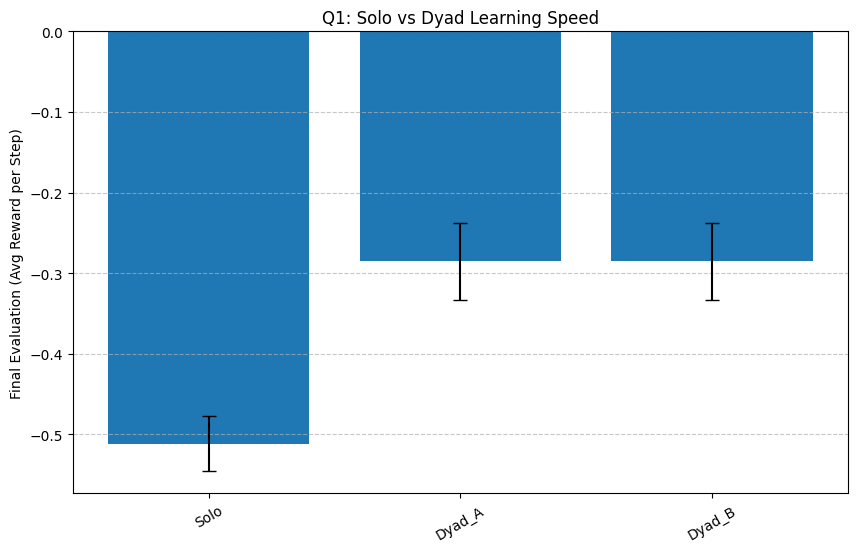

In [6]:
# ======================================================
# Utilities
# ======================================================

def evaluate_agent(env, agent, n_episodes=50):
    """Evaluate agent solo without learning updates."""
    rewards = []
    for ep in range(n_episodes):
        s = env.reset()
        done = False
        ep_reward, steps = 0, 0
        while not done:
            a = agent.generate_action(s, env.allowed_actions(s))  # greedy
            s_next, r, done, _ = env.step(a)
            ep_reward += r
            steps += 1
            s = s_next
        rewards.append(ep_reward / steps if steps > 0 else 0.0)
    return np.mean(rewards)


def run_multiple(experiment_fn, n_runs=5, eval_episodes=50, **kwargs):
    """Repeat experiment across seeds, return dict of results {condition: [scores]}."""
    results = {}
    for run in range(n_runs):
        seed = 123 + run
        env = PianoEnv(length=50, n_actions=60, seed=seed)
        exp_results = experiment_fn(env, **kwargs)
        for label, agent in exp_results.items():
            score = evaluate_agent(env, agent, eval_episodes)
            results.setdefault(label, []).append(score)
    return results


def plot_results(results, title):
    mean_final = {k: np.mean(v) for k, v in results.items()}
    std_final  = {k: np.std(v) for k, v in results.items()}

    plt.figure(figsize=(10,6))
    labels = list(mean_final.keys())
    means = [mean_final[k] for k in labels]
    stds  = [std_final[k] for k in labels]

    plt.bar(labels, means, yerr=stds, capsize=5)
    plt.xticks(rotation=30)
    plt.ylabel("Final Evaluation (Avg Reward per Step)")
    plt.title(title)
    plt.grid(True, axis="y", linestyle="--", alpha=0.7)
    plt.show()


# ======================================================
# Experiments
# ======================================================

# Q1: Solo vs Dyad
def exp_q1(env, n_episodes=100):
    solo = QLearningAgent(env.n_states, env.n_actions)
    run_solo(env, solo, n_episodes)

    a, b = QLearningAgent(env.n_states, env.n_actions), QLearningAgent(env.n_states, env.n_actions)
    run_dyad(env, a, b, n_episodes*2, swap_mode="episode", obs_factor=0.7)

    return {"Solo": solo, "Dyad_A": a, "Dyad_B": b}

results_q1 = run_multiple(exp_q1, n_runs=5, n_episodes=5)
plot_results(results_q1, "Q1: Solo vs Dyad Learning Speed")


Correct map: [14, 3, 35, 31, 28, 17, 13, 69, 11, 75, 54, 4, 3, 11, 27, 29, 64, 77, 3, 71, 25, 69, 53, 28, 57, 75, 35, 0, 20, 54, 43, 35, 19, 27, 43, 13, 11, 48, 12, 45, 44, 77, 33, 5, 58, 68, 15, 48, 10, 70]
[-0.043999999999999886, -0.008000000000000078, -0.007999999999999919, 0.010000000000000111, 0.046000000000000166] in dyad
[-0.008000000000000016, 0.010000000000000075, 0.028000000000000184, 0.045999999999999985, 0.21379310344827604] in dyad
[-0.06199999999999989, -0.02600000000000004, -0.007999999999999776, 0.010000000000000075, 0.0460000000000001] in dyad
[-0.06200000000000014, -0.04400000000000003, -0.008000000000000016, 0.010000000000000075, 0.010000000000000182] in dyad
[-0.06200000000000003, -0.008000000000000182, -0.007999999999999919, 0.010000000000000111, 0.028000000000000035] in dyad
[-0.06200000000000014, -0.04400000000000017, -0.008000000000000016, 0.010000000000000253, 0.027999999999999962] in dyad


[-0.06200000000000006, -0.04400000000000003, -0.008000000000000016, 0.010000000000000085, 0.010000000000000182] in dyad
[-0.04400000000000003, -0.008000000000000016, 0.010000000000000085, 0.009999999999999969, 0.046000000000000166] in dyad
[-0.06200000000000006, -0.04400000000000004, -0.007999999999999882, 0.010000000000000217, 0.027999999999999973] in dyad
[-0.06200000000000003, -0.007999999999999929, -0.007999999999999919, 0.010000000000000111, 0.04599999999999996] in dyad
[-0.04400000000000004, -0.008000000000000123, 0.010000000000000075, 0.009999999999999969, 0.04600000000000013] in dyad
[-0.06199999999999989, -0.025999999999999898, -0.007999999999999919, 0.010000000000000075, 0.02799999999999982] in dyad
[-0.06200000000000024, -0.02599999999999996, -0.007999999999999919, 0.010000000000000075, 0.027999999999999973] in dyad
[-0.04400000000000011, -0.008000000000000016, 0.010000000000000075, 0.028000000000000115, 0.046000000000000166] in dyad
[-0.04400000000000014, -0.008000000000000

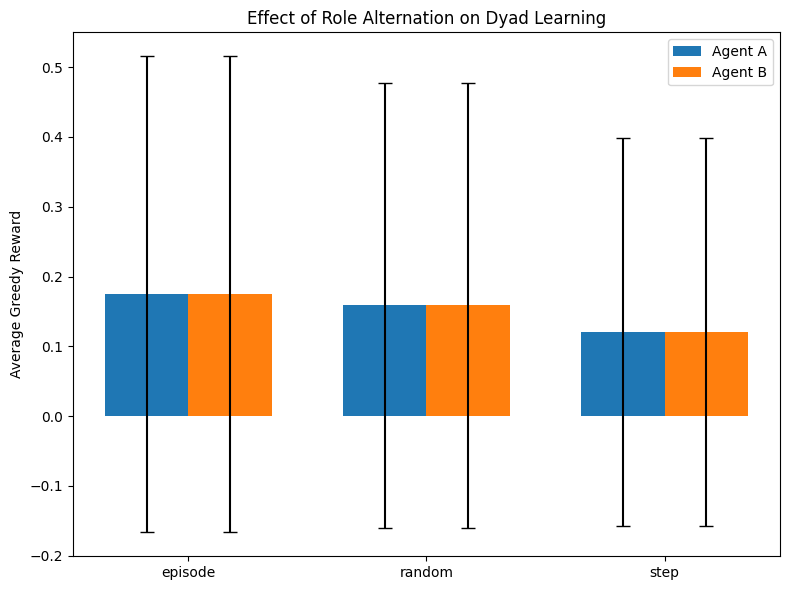

In [41]:
import pandas as pd
#EXP 3
#different switch modes
def evaluate_agent(env, agent, n_eval_episodes=5):
    total_rewards = []
    for _ in range(n_eval_episodes):
        s = env.reset()
        done = False
        ep_reward = 0
        while not done:
            a = np.argmax(agent.Q[s])  # greedy action
            s, r, done, _ = env.step(a)
            ep_reward += r
        total_rewards.append(ep_reward/env.steps)
    return np.mean(total_rewards)

# ------------------------------
# One experiment run
# ------------------------------
def exp_q2(env, n_episodes=50, mode="episode", obs_factor=0.7, n_eval_episodes=10):
    a, b = QLearningAgent(env.n_states, env.n_actions), QLearningAgent(env.n_states, env.n_actions)
    run_dyad(env, a, b, n_episodes=n_episodes, swap_mode=mode, obs_factor=obs_factor)
    eval_a = evaluate_agent(env, a, n_eval_episodes=n_eval_episodes)
    eval_b = evaluate_agent(env, b, n_eval_episodes=n_eval_episodes)
    return {f"Dyad-{mode}_A": eval_a, f"Dyad-{mode}_B": eval_b}

# ------------------------------
# Multiple runs wrapper
# ------------------------------
def run_multiple(env, modes, n_runs=5, n_episodes=50, obs_factor=0.7, n_eval_episodes=10):
    results = []
    for m in modes:
        for run in range(n_runs):
            out = exp_q2(env, n_episodes=n_episodes, mode=m, obs_factor=obs_factor, n_eval_episodes=n_eval_episodes)
            for label, score in out.items():
                agent = label.split("_")[-1]  # A or B
                results.append({"mode": m, "agent": agent, "score": score})
    return pd.DataFrame(results)

# ------------------------------
# Plotting
# ------------------------------
def plot_results(df, title="Dyad Role Alternation Comparison"):
    stats = df.groupby(["mode", "agent"])["score"].agg(["mean", "std"]).reset_index()

    plt.figure(figsize=(8,6))
    modes = stats["mode"].unique()
    agents = stats["agent"].unique()
    x = np.arange(len(modes))
    width = 0.35

    for i, agent in enumerate(agents):
        vals = stats[stats["agent"] == agent]
        plt.bar(x + i*width - width/2, vals["mean"], width, yerr=vals["std"], capsize=5, label=f"Agent {agent}")

    plt.xticks(x, modes)
    plt.ylabel("Average Greedy Reward")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

# ------------------------------
# Run the full experiment
# ------------------------------
if __name__ == "__main__":
    env = PianoEnv(length=50, n_actions=80, seed=42)  # replace with PianoEnv
    modes = ["episode", "step", "random"]
    df = run_multiple(env, modes, n_runs=200, n_episodes=25, obs_factor=0.8, n_eval_episodes=20)
    print(df.groupby(["mode", "agent"]).agg(["mean", "std"]))
    plot_results(df, title="Effect of Role Alternation on Dyad Learning")

Correct map: [14, 3, 35, 31, 28, 17, 13, 69, 11, 75, 54, 4, 3, 11, 27, 29, 64, 77, 3, 71, 25, 69, 53, 28, 57, 75, 35, 0, 20, 54, 43, 35, 19, 27, 43, 13, 11, 48, 12, 45, 44, 77, 33, 5, 58, 68, 15, 48, 10, 70]


                     score          
                      mean       std
obs_factor agent                    
0.1        A      0.001684  0.012900
           B      0.001684  0.012900
0.2        A      0.001432  0.011697
           B      0.001432  0.011697
0.3        A      0.004852  0.046528
           B      0.004852  0.046528
0.4        A      0.001576  0.012019
           B      0.001576  0.012019
0.5        A      0.004096  0.046206
           B      0.004096  0.046206
0.6        A      0.009496  0.089923
           B      0.009496  0.089923
0.7        A      0.001612  0.011351
           B      0.001612  0.011351
0.8        A      0.006004  0.064203
           B      0.006004  0.064203
0.9        A      0.005860  0.064395
           B      0.005860  0.064395


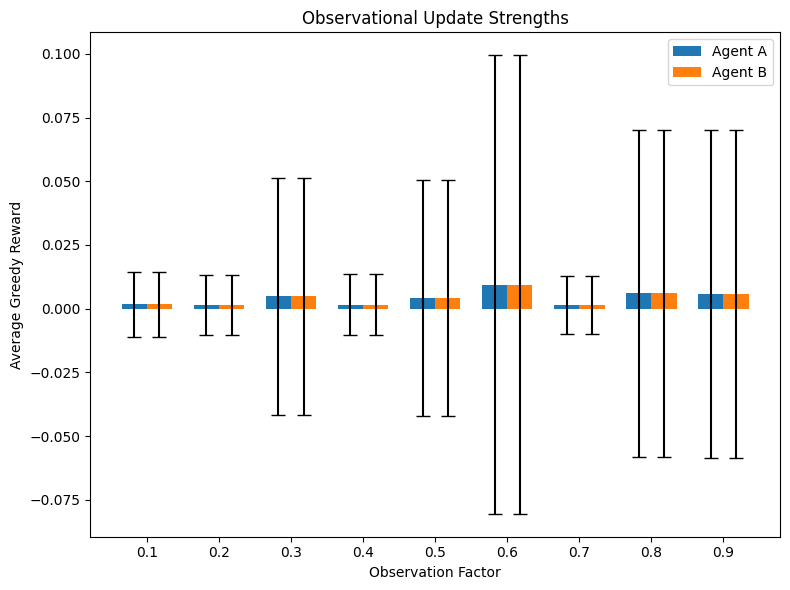

In [6]:
# different obs-factor for the observational update

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------
# Greedy evaluation
# ------------------------------
def evaluate_agent(env, agent, n_eval_episodes=10):
    total_rewards = []
    for _ in range(n_eval_episodes):
        s = env.reset()
        done = False
        ep_reward = 0
        while not done:
            a = np.argmax(agent.Q[s])
            s, r, done, _ = env.step(a)
            ep_reward += r
        total_rewards.append(ep_reward/env.steps)
    return np.mean(total_rewards)

# ------------------------------



# ------------------------------
# Q3: Observation factor experiment
# ------------------------------
def exp_q3(env, obs_factors=[0.1, 0.3, 0.7], n_runs=10, n_episodes=50, n_eval_episodes=20):
    results = []
    for obs in obs_factors:
        for run in range(n_runs):
            a, b = QLearningAgent(env.n_states, env.n_actions), QLearningAgent(env.n_states, env.n_actions)
            run_dyad(env, a, b, n_episodes=n_episodes, swap_mode="episode", obs_factor=obs)
            eval_a = evaluate_agent(env, a, n_eval_episodes)
            eval_b = evaluate_agent(env, b, n_eval_episodes)
            results.append({"obs_factor": obs, "agent": "A", "score": eval_a})
            results.append({"obs_factor": obs, "agent": "B", "score": eval_b})
    return pd.DataFrame(results)

# ------------------------------
# Plotting results
# ------------------------------
def plot_q3(df, title="Observational Update Strengths"):
    stats = df.groupby(["obs_factor", "agent"])["score"].agg(["mean", "std"]).reset_index()

    plt.figure(figsize=(8,6))
    obs_vals = stats["obs_factor"].unique()
    agents = stats["agent"].unique()
    x = np.arange(len(obs_vals))
    width = 0.35

    for i, agent in enumerate(agents):
        vals = stats[stats["agent"] == agent]
        plt.bar(x + i*width - width/2, vals["mean"], width, yerr=vals["std"], capsize=5, label=f"Agent {agent}")

    plt.xticks(x, obs_vals)
    plt.xlabel("Observation Factor")
    plt.ylabel("Average Greedy Reward")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

# ------------------------------
# Run Q3 Experiment
# ------------------------------
if __name__ == "__main__":
    env = PianoEnv(length=50, n_actions=80, seed=42)  # replace with PianoEnv
    df_q3 = exp_q3(env, obs_factors=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9], n_runs=500, n_episodes=23, n_eval_episodes=5)
    print(df_q3.groupby(["obs_factor", "agent"]).agg(["mean", "std"]))
    plot_q3(df_q3)

In [ ]:


# Q4: Divergence effects
def init_agent(divergent=False):
    ag = QLearningAgent(env.n_states, env.n_actions)
    if divergent:
        ag.Q = np.random.uniform(-1, 1, size=ag.Q.shape)
    return ag

def exp_q4(env, n_episodes=100, d1=False, d2=False, label="pair"):
    a, b = init_agent(d1), init_agent(d2)
    run_dyad(env, a, b, n_episodes)
    return {f"{label}_A": a, f"{label}_B": b}

pairs = [(False, False, "Both-similar"), (True, True, "Both-divergent"), (False, True, "Mixed")]
for d1, d2, label in pairs:
    results_q4 = run_multiple(exp_q4, n_runs=5, n_episodes=100, d1=d1, d2=d2, label=label)
    plot_results(results_q4, f"Q4: Divergence ({label})")


# Q5: Matching learners by skill
def run_matching(env, high_skill_a=True, high_skill_b=False, n_episodes=100, label="pair"):
    a, b = QLearningAgent(env.n_states, env.n_actions), QLearningAgent(env.n_states, env.n_actions)
    if high_skill_a:
        a.Q += np.random.uniform(0, 1, size=a.Q.shape)
    if high_skill_b:
        b.Q += np.random.uniform(0, 1, size=b.Q.shape)
    run_dyad(env, a, b, n_episodes)
    return {f"{label}_A": a, f"{label}_B": b}

configs = [(True, True, "High-High"), (False, False, "Low-Low"), (True, False, "High-Low")]
for ha, hb, label in configs:
    results_q5 = run_multiple(run_matching, n_runs=5, n_episodes=100, 
                              high_skill_a=ha, high_skill_b=hb, label=label)
    plot_results(results_q5, f"Q5: Matching Strategy ({label})")


# Q6: Error analysis proxy (kept as before, not a bar-plot evaluation)
def run_error_analysis(env, a, b, n_episodes=100):
    error_scores = []
    for ep in range(n_episodes):
        s = env.reset()
        done = False
        while not done:
            action_perf = a.act(s, env.allowed_actions(s))
            action_coach = b.generate_action(s, env.allowed_actions(s))
            optimal = (s % env.n_actions)
            coach_better = (action_coach != action_perf) and (action_coach == optimal)
            error_scores.append(int(coach_better))
            s, _, done, _ = env.step(action_perf)
    return np.mean(error_scores)

A, B = QLearningAgent(env.n_states, env.n_actions), QLearningAgent(env.n_states, env.n_actions)
score = run_error_analysis(PianoEnv(), A, B)
print("Q6: Error analysis proxy (fraction coach closer to optimal):", score)


TypeError: run_multiple() got an unexpected keyword argument 'd1'